# Raw Dataset Label Histogram Analysis

This notebook scans the flat YOLO dataset in `raw_dataset`, summarizes label imbalance by annotation count, and renders a histogram of class frequency.


In [7]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "PIL": "pillow",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
RAW_DATASET_DIR = Path("raw_dataset_balanced")
CLASS_NAMES = {0: "undefected", 1: "dirt_defect", 2: "shape_defect"}
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SAVE_FIGURES = False
FIGURE_OUTPUT_PATH = ROOT / "raw_dataset_label_histogram.png"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

assert RAW_DATASET_DIR.exists(), f"Dataset directory not found: {RAW_DATASET_DIR.resolve()}"

print(f"ROOT: {ROOT}")
print(f"RAW_DATASET_DIR: {RAW_DATASET_DIR.resolve()}")
print(f"CLASS_NAMES: {CLASS_NAMES}")
print(f"SAVE_FIGURES: {SAVE_FIGURES}")


ROOT: C:\Users\mohamed\coding\detectx
RAW_DATASET_DIR: C:\Users\mohamed\coding\detectx\raw_dataset_balanced
CLASS_NAMES: {0: 'undefected', 1: 'dirt_defect', 2: 'shape_defect'}
SAVE_FIGURES: False


In [9]:
dataset_entries = sorted(path for path in RAW_DATASET_DIR.iterdir() if path.is_file())
image_paths = sorted(path for path in dataset_entries if path.suffix.lower() in IMAGE_SUFFIXES)
label_paths = sorted(path for path in dataset_entries if path.suffix.lower() == ".txt")

image_by_stem = {path.stem: path for path in image_paths}
label_by_stem = {path.stem: path for path in label_paths}

missing_image_for_label = sorted(stem for stem in label_by_stem if stem not in image_by_stem)
missing_label_for_image = sorted(stem for stem in image_by_stem if stem not in label_by_stem)

annotation_records = []
empty_label_files = []
invalid_rows = []

for label_path in label_paths:
    file_id = label_path.stem
    image_path = image_by_stem.get(file_id)
    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]

    if not lines:
        empty_label_files.append(label_path.name)
        continue

    for row_number, line in enumerate(lines, start=1):
        parts = line.split()
        if len(parts) != 5:
            invalid_rows.append(
                {
                    "label_name": label_path.name,
                    "row_number": row_number,
                    "raw_line": line,
                    "reason": "Expected 5 YOLO fields.",
                }
            )
            continue

        class_id_text, x_center_text, y_center_text, width_text, height_text = parts

        try:
            class_id = int(class_id_text)
            x_center = float(x_center_text)
            y_center = float(y_center_text)
            width = float(width_text)
            height = float(height_text)
        except ValueError:
            invalid_rows.append(
                {
                    "label_name": label_path.name,
                    "row_number": row_number,
                    "raw_line": line,
                    "reason": "Failed to parse numeric YOLO values.",
                }
            )
            continue

        annotation_records.append(
            {
                "file_id": file_id,
                "image_name": image_path.name if image_path else None,
                "label_name": label_path.name,
                "class_id": class_id,
                "class_name": CLASS_NAMES.get(class_id, f"unknown_{class_id}"),
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
                "box_area": width * height,
            }
        )

annotation_columns = [
    "file_id",
    "image_name",
    "label_name",
    "class_id",
    "class_name",
    "x_center",
    "y_center",
    "width",
    "height",
    "box_area",
]

annotations_df = pd.DataFrame(annotation_records, columns=annotation_columns)
empty_labels_df = pd.DataFrame({"label_name": empty_label_files})
invalid_rows_df = pd.DataFrame(invalid_rows)

class_order = sorted(CLASS_NAMES)
class_summary = pd.DataFrame(
    {
        "class_id": class_order,
        "class_name": [CLASS_NAMES[class_id] for class_id in class_order],
    }
)

if annotations_df.empty:
    class_counts = pd.Series(data=[0] * len(class_order), index=class_order)
else:
    class_counts = annotations_df["class_id"].value_counts().reindex(class_order, fill_value=0)

class_summary["annotation_count"] = class_summary["class_id"].map(class_counts).astype(int)
total_annotations = int(class_summary["annotation_count"].sum())
if total_annotations > 0:
    class_summary["annotation_pct"] = (class_summary["annotation_count"] / total_annotations * 100.0).round(2)
else:
    class_summary["annotation_pct"] = 0.0

summary_metrics = {
    "total_image_files": len(image_paths),
    "total_label_files": len(label_paths),
    "total_annotations": total_annotations,
    "empty_label_files": len(empty_label_files),
    "missing_images_for_labels": len(missing_image_for_label),
    "missing_labels_for_images": len(missing_label_for_image),
    "invalid_rows": len(invalid_rows),
}

print("Dataset scan completed.")
print(summary_metrics)
display(class_summary)


Dataset scan completed.
{'total_image_files': 2948, 'total_label_files': 2948, 'total_annotations': 2948, 'empty_label_files': 0, 'missing_images_for_labels': 0, 'missing_labels_for_images': 0, 'invalid_rows': 0}


,class_id,class_name,annotation_count,annotation_pct
0,0,undefected,1092,37.04
1,1,dirt_defect,1092,37.04
2,2,shape_defect,764,25.92


In [10]:
non_zero_counts = class_summary.loc[class_summary["annotation_count"] > 0, "annotation_count"]
imbalance_ratio = float(non_zero_counts.max() / non_zero_counts.min()) if not non_zero_counts.empty else float("nan")

summary_table = class_summary.copy()
summary_table["annotation_pct"] = summary_table["annotation_pct"].map(lambda value: f"{value:.2f}%")

print(f"Total image files: {len(image_paths)}")
print(f"Total label files: {len(label_paths)}")
print(f"Total annotations: {total_annotations}")
print(f"Empty label files: {len(empty_label_files)}")
print(f"Missing image files for labels: {len(missing_image_for_label)}")
print(f"Missing label files for images: {len(missing_label_for_image)}")
print(f"Majority/minority imbalance ratio: {imbalance_ratio:.2f}x")

display(summary_table)


Total image files: 2948
Total label files: 2948
Total annotations: 2948
Empty label files: 0
Missing image files for labels: 0
Missing label files for images: 0
Majority/minority imbalance ratio: 1.43x


,class_id,class_name,annotation_count,annotation_pct
0,0,undefected,1092,37.04%
1,1,dirt_defect,1092,37.04%
2,2,shape_defect,764,25.92%


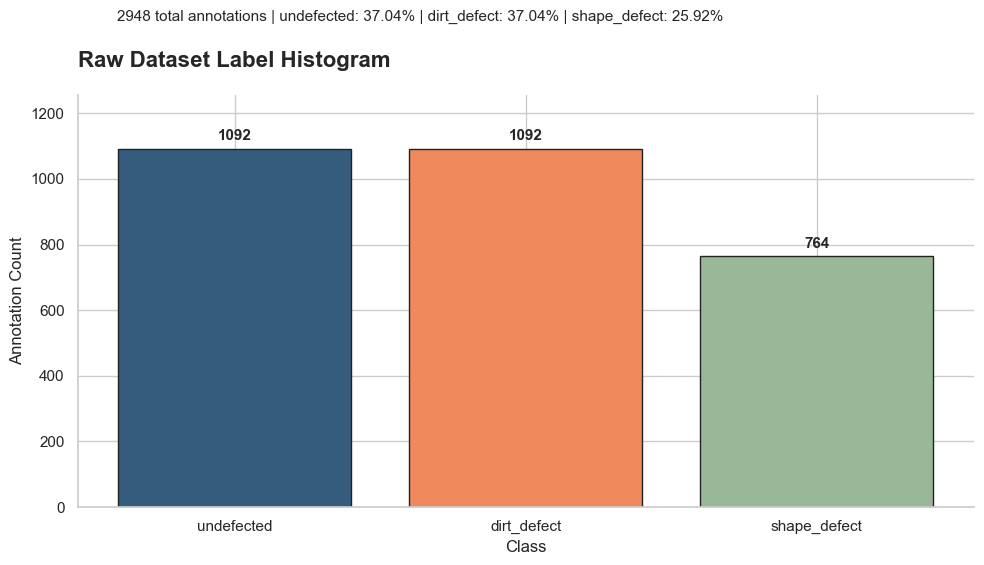

In [11]:
plot_df = class_summary.copy()
plot_df["annotation_label"] = plot_df["annotation_count"].astype(str)
subtitle = " | ".join(
    f"{row.class_name}: {row.annotation_pct:.2f}%"
    for row in plot_df.itertuples(index=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    plot_df["class_name"],
    plot_df["annotation_count"],
    color=["#355C7D", "#F08A5D", "#99B898"],
    edgecolor="#222222",
    linewidth=1.0,
)

max_count = max(plot_df["annotation_count"].max(), 1)
for bar, row in zip(bars, plot_df.itertuples(index=False)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_count * 0.015,
        f"{row.annotation_count}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title("Raw Dataset Label Histogram", loc="left", fontsize=16, fontweight="bold", pad=20)
fig.text(0.125, 0.92, f"{total_annotations} total annotations | {subtitle}", ha="left", fontsize=11)
ax.set_xlabel("Class")
ax.set_ylabel("Annotation Count")
ax.set_ylim(0, max_count * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.9])

if SAVE_FIGURES:
    fig.savefig(FIGURE_OUTPUT_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved figure to {FIGURE_OUTPUT_PATH}")

plt.show()


In [12]:
if total_annotations == 0:
    print("No annotations were found in the dataset.")
else:
    majority_row = class_summary.loc[class_summary["annotation_count"].idxmax()]
    minority_candidates = class_summary.loc[class_summary["annotation_count"] > 0]
    minority_row = minority_candidates.loc[minority_candidates["annotation_count"].idxmin()]
    imbalance_ratio = majority_row["annotation_count"] / minority_row["annotation_count"]

    print(
        f"Majority class: {majority_row['class_name']} with {int(majority_row['annotation_count'])} annotations "
        f"({majority_row['annotation_pct']:.2f}%)."
    )
    print(
        f"Minority class: {minority_row['class_name']} with {int(minority_row['annotation_count'])} annotations "
        f"({minority_row['annotation_pct']:.2f}%)."
    )
    print(f"The majority class has {imbalance_ratio:.2f}x more annotations than the minority class.")
    print(f"Empty label files detected: {len(empty_label_files)}")
    print(f"Missing image files for labels: {len(missing_image_for_label)}")
    print(f"Missing label files for images: {len(missing_label_for_image)}")

    if empty_label_files:
        print(f"Empty label file names: {', '.join(empty_label_files[:10])}")

    if not invalid_rows_df.empty:
        print("Invalid label rows were detected:")
        display(invalid_rows_df.head())
    else:
        print("No invalid label rows were detected.")


Majority class: undefected with 1092 annotations (37.04%).
Minority class: shape_defect with 764 annotations (25.92%).
The majority class has 1.43x more annotations than the minority class.
Empty label files detected: 0
Missing image files for labels: 0
Missing label files for images: 0
No invalid label rows were detected.
